# LSTM for Stock Price Prediction

This notebook implements a Long Short-Term Memory (LSTM) network to predict RELIANCE.NS stock price direction (up/down).

## Key Components:
- **Framework**: PyTorch LSTM
- **Architecture**: Multi-layer LSTM with dropout
- **Dataset**: RELIANCE.NS (Mar 2025 - Mar 2026)
- **Task**: Binary classification (next day up/down)
- **Purpose**: Baseline comparison for SNN model

## 1. Import Libraries and Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
import time
import pickle
import os

# Import data preparation module
from data_preparation import prepare_full_dataset

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create output directory
os.makedirs('outputs/lstm', exist_ok=True)

%matplotlib inline
sns.set_style('whitegrid')

Using device: cuda


## 2. Load and Prepare Data

In [2]:
# Prepare dataset (using same data as SNN)
print("Preparing stock dataset...\n")
data_dict = prepare_full_dataset(
    ticker="RELIANCE.NS",
    start="2025-03-04",
    end="2026-03-04",
    seq_len=20,
    train_ratio=0.8,
    save_path="./processed_data"
)

train_dataset = data_dict['train_dataset']
test_dataset = data_dict['test_dataset']
num_features = data_dict['num_features']
feature_cols = data_dict['feature_cols']

print(f"\nNumber of input features: {num_features}")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Preparing stock dataset...

Downloaded 247 trading days
Added technical indicators. Total features: 27
Target created: 97/198 up days (49.0%)
Train set: 158 days
Test set: 40 days

Creating training dataset...
Created dataset: 138 sequences of shape (20, 27)
Positive class ratio: 0.500

Creating testing dataset...
Created dataset: 20 sequences of shape (20, 27)
Positive class ratio: 0.500

Data saved to ./processed_data

Number of input features: 27
Training samples: 138
Testing samples: 20


In [3]:
# Create data loaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 5
Test batches: 1


## 3. Define LSTM Model Architecture

In [4]:
class LSTMStockPredictor(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, num_classes=2, dropout=0.3):
        super(LSTMStockPredictor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Fully connected layers
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size // 2, num_classes)
        
    def forward(self, x):
        # x shape: (batch, seq_len, features)
        
        # LSTM forward pass
        lstm_out, (hn, cn) = self.lstm(x)
        
        # Use the last hidden state
        out = hn[-1]  # (batch, hidden_size)
        
        # Fully connected layers
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out
    
    def get_hidden_states(self, x):
        """Get hidden states for visualization"""
        lstm_out, (hn, cn) = self.lstm(x)
        return lstm_out.detach().cpu().numpy(), hn.detach().cpu().numpy()

In [5]:
# Initialize model
model = LSTMStockPredictor(
    input_size=num_features,
    hidden_size=128,
    num_layers=2,
    num_classes=2,
    dropout=0.3
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

LSTMStockPredictor(
  (lstm): LSTM(27, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

Total parameters: 220866


## 4. Training Setup

In [6]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

# Training parameters
num_epochs = 100
print_interval = 10

## 5. Training Loop

In [7]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
    'test_f1': [],
    'test_precision': [],
    'test_recall': []
}

best_test_acc = 0.0
best_model_state = None

print("Starting training...\n")
start_time = time.time()

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += targets.size(0)
        train_correct += predicted.eq(targets).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    # Testing phase
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    
    test_loss /= len(test_loader)
    test_acc = accuracy_score(all_targets, all_preds) * 100
    test_f1 = f1_score(all_targets, all_preds)
    test_precision = precision_score(all_targets, all_preds)
    test_recall = recall_score(all_targets, all_preds)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['test_f1'].append(test_f1)
    history['test_precision'].append(test_precision)
    history['test_recall'].append(test_recall)
    
    # Save best model
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state = model.state_dict().copy()
    
    # Print progress
    if (epoch + 1) % print_interval == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
        print(f"  Test F1: {test_f1:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}")
        print()
    
    scheduler.step()

training_time = time.time() - start_time
print(f"Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"Best test accuracy: {best_test_acc:.2f}%")

# Load best model
model.load_state_dict(best_model_state)
torch.save(model.state_dict(), 'outputs/lstm/best_model.pth')
print("Best model saved to outputs/lstm/best_model.pth")

Starting training...



/media/aejaz/New Volume/Projects/SNN/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/aejaz/New Volume/Projects/SNN/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/aejaz/New Volume/Projects/SNN/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

Epoch [1/100]
  Train Loss: 0.6972, Train Acc: 50.00%
  Test Loss: 0.6946, Test Acc: 50.00%
  Test F1: 0.0000, Precision: 0.0000, Recall: 0.0000

Epoch [10/100]
  Train Loss: 0.6853, Train Acc: 58.70%
  Test Loss: 0.7049, Test Acc: 40.00%
  Test F1: 0.0000, Precision: 0.0000, Recall: 0.0000

Epoch [20/100]
  Train Loss: 0.6327, Train Acc: 64.49%
  Test Loss: 0.7364, Test Acc: 50.00%
  Test F1: 0.4444, Precision: 0.5000, Recall: 0.4000

Epoch [30/100]
  Train Loss: 0.6185, Train Acc: 65.22%
  Test Loss: 0.7039, Test Acc: 55.00%
  Test F1: 0.6087, Precision: 0.5385, Recall: 0.7000

Epoch [40/100]
  Train Loss: 0.5625, Train Acc: 68.84%
  Test Loss: 0.6957, Test Acc: 45.00%
  Test F1: 0.5926, Precision: 0.4706, Recall: 0.8000

Epoch [50/100]
  Train Loss: 0.5469, Train Acc: 68.12%
  Test Loss: 0.7212, Test Acc: 45.00%
  Test F1: 0.6207, Precision: 0.4737, Recall: 0.9000

Epoch [60/100]
  Train Loss: 0.5177, Train Acc: 73.91%
  Test Loss: 0.6916, Test Acc: 55.00%
  Test F1: 0.6087, Precisi

## 6. Training Visualization

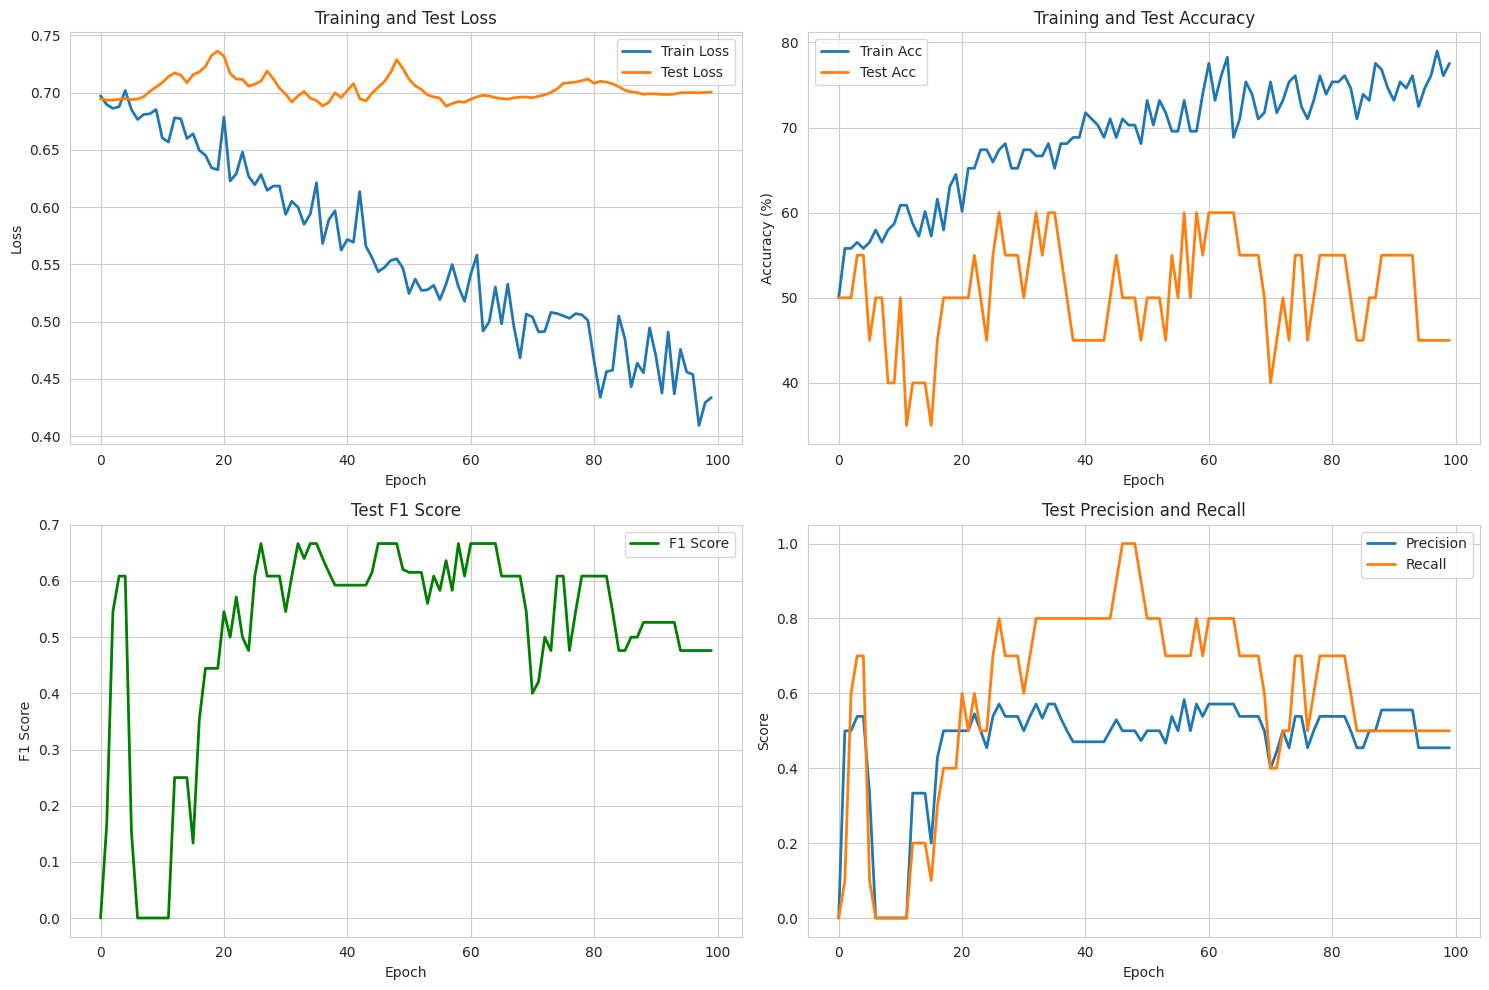

Training history plot saved to outputs/lstm/training_history.png


In [8]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['test_loss'], label='Test Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Test Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train Acc', linewidth=2)
axes[0, 1].plot(history['test_acc'], label='Test Acc', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Test Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# F1 Score
axes[1, 0].plot(history['test_f1'], label='F1 Score', linewidth=2, color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Test F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Precision and Recall
axes[1, 1].plot(history['test_precision'], label='Precision', linewidth=2)
axes[1, 1].plot(history['test_recall'], label='Recall', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Test Precision and Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('outputs/lstm/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training history plot saved to outputs/lstm/training_history.png")

## 7. Final Evaluation

In [9]:
# Evaluate on test set
model.eval()
all_preds = []
all_targets = []
all_probs = []

inference_times = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Measure inference time
        start = time.time()
        outputs = model(inputs)
        inference_times.append(time.time() - start)
        
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # Probability of class 1

# Calculate metrics
accuracy = accuracy_score(all_targets, all_preds)
f1 = f1_score(all_targets, all_preds)
precision = precision_score(all_targets, all_preds)
recall = recall_score(all_targets, all_preds)
conf_matrix = confusion_matrix(all_targets, all_preds)

avg_inference_time = np.mean(inference_times) * 1000  # Convert to ms

print("=" * 60)
print("LSTM FINAL EVALUATION METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Avg Inference Time: {avg_inference_time:.2f} ms/batch")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(all_targets, all_preds, target_names=['Down', 'Up']))

LSTM FINAL EVALUATION METRICS
Accuracy:  45.00%
F1 Score:  0.4762
Precision: 0.4545
Recall:    0.5000
Avg Inference Time: 0.34 ms/batch

Classification Report:
              precision    recall  f1-score   support

        Down       0.44      0.40      0.42        10
          Up       0.45      0.50      0.48        10

    accuracy                           0.45        20
   macro avg       0.45      0.45      0.45        20
weighted avg       0.45      0.45      0.45        20



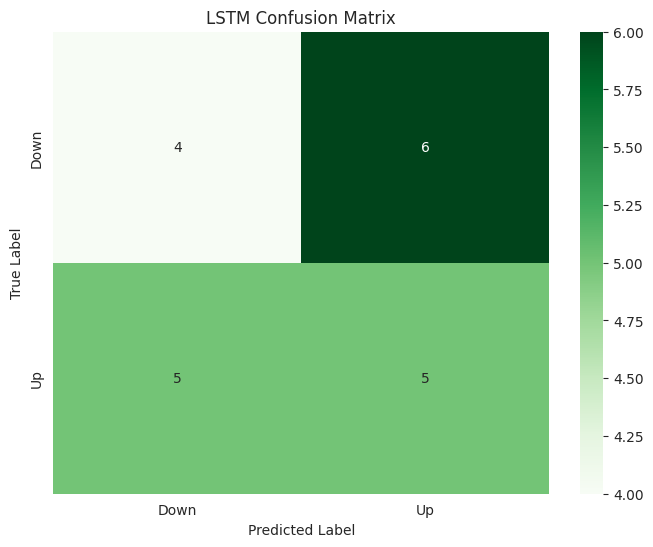

Confusion matrix saved to outputs/lstm/confusion_matrix.png


In [10]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.title('LSTM Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('outputs/lstm/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved to outputs/lstm/confusion_matrix.png")

## 8. LSTM Hidden States Visualization

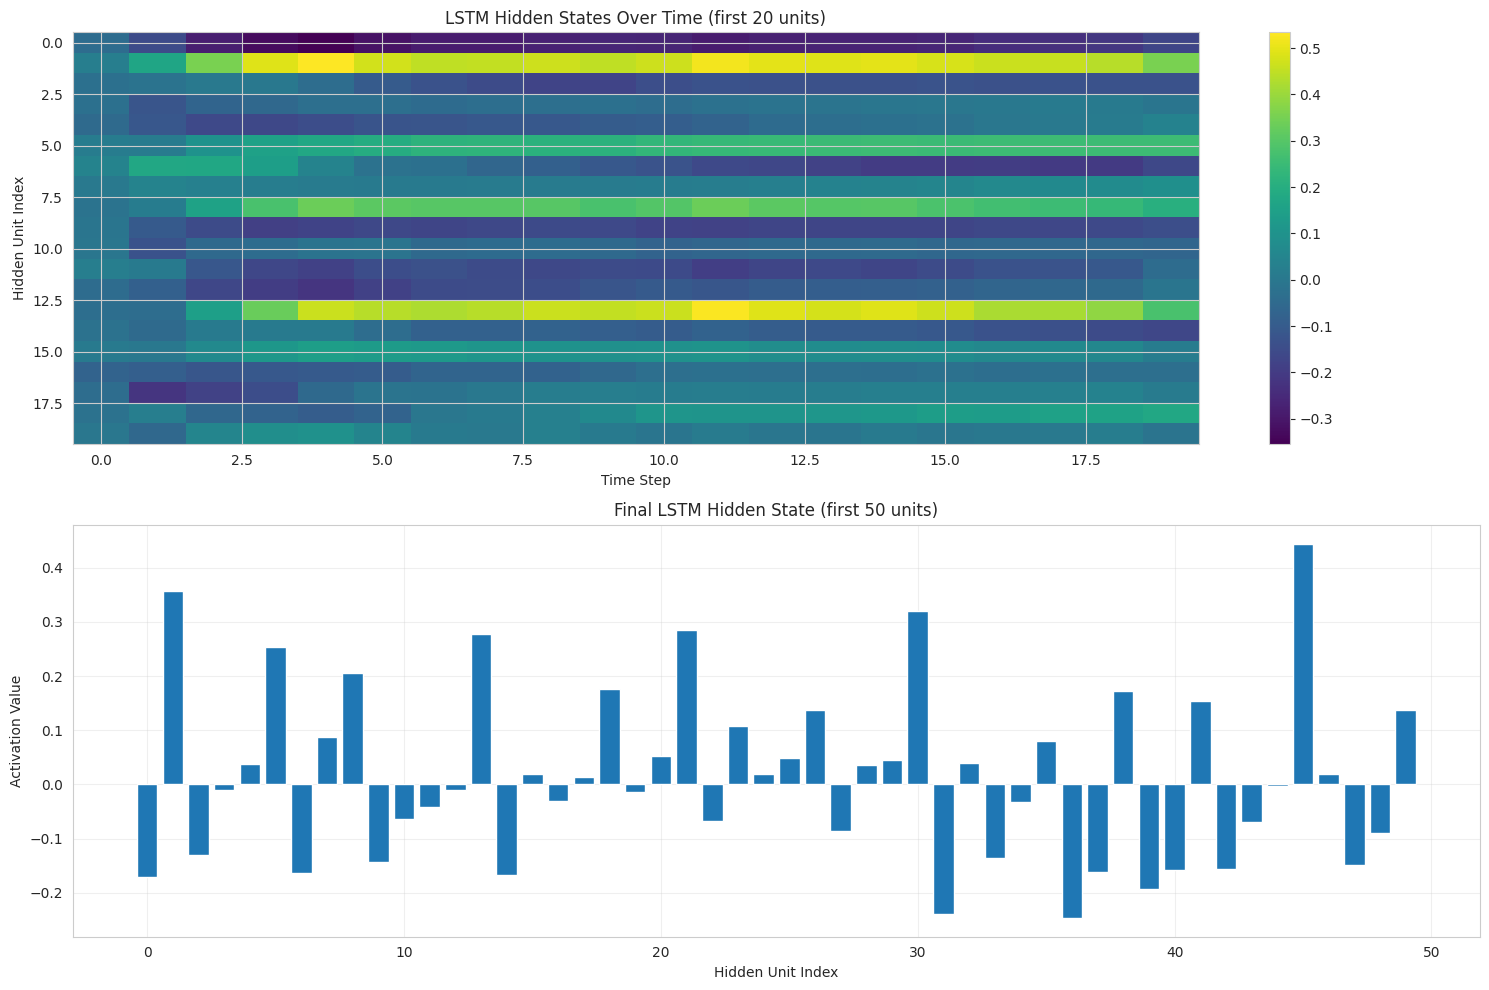

Hidden states visualization saved to outputs/lstm/hidden_states.png


In [11]:
# Visualize LSTM hidden states
model.eval()

# Get a batch
sample_batch, _ = next(iter(test_loader))
sample_input = sample_batch[:1].to(device)  # Take first sample

# Get hidden states
with torch.no_grad():
    lstm_out, hn = model.get_hidden_states(sample_input)

# Plot hidden states over time
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# LSTM output over timesteps
lstm_sample = lstm_out[0, :, :20]  # First sample, first 20 hidden units
im1 = axes[0].imshow(lstm_sample.T, aspect='auto', cmap='viridis', interpolation='nearest')
axes[0].set_ylabel('Hidden Unit Index')
axes[0].set_xlabel('Time Step')
axes[0].set_title('LSTM Hidden States Over Time (first 20 units)')
plt.colorbar(im1, ax=axes[0])

# Final hidden state
final_hidden = hn[-1, 0, :50]  # Last layer, first sample, first 50 units
axes[1].bar(range(len(final_hidden)), final_hidden)
axes[1].set_xlabel('Hidden Unit Index')
axes[1].set_ylabel('Activation Value')
axes[1].set_title('Final LSTM Hidden State (first 50 units)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/lstm/hidden_states.png', dpi=300, bbox_inches='tight')
plt.show()

print("Hidden states visualization saved to outputs/lstm/hidden_states.png")

## 9. Backtesting Simulation

In [12]:
# Simple backtesting: long on up predictions, short on down predictions
test_df = data_dict['test_df'].iloc[20:]  # Skip first seq_len samples
test_df = test_df.reset_index()

# Add predictions
test_df['Predicted'] = all_preds[:len(test_df)]
test_df['Correct'] = (test_df['Predicted'] == test_df['Target']).astype(int)

# Calculate strategy returns
test_df['Returns'] = test_df['Close'].pct_change()
test_df['Strategy_Returns'] = test_df['Returns'] * (test_df['Predicted'] * 2 - 1)  # +1 for up, -1 for down

# Cumulative returns
test_df['Cumulative_Returns'] = (1 + test_df['Returns']).cumprod() - 1
test_df['Cumulative_Strategy_Returns'] = (1 + test_df['Strategy_Returns']).cumprod() - 1

# Calculate Sharpe ratio (assuming 252 trading days)
sharpe_ratio = test_df['Strategy_Returns'].mean() / test_df['Strategy_Returns'].std() * np.sqrt(252)

print("\n" + "=" * 60)
print("BACKTESTING RESULTS")
print("=" * 60)
print(f"Total Return (Buy & Hold): {test_df['Cumulative_Returns'].iloc[-1]*100:.2f}%")
print(f"Total Return (Strategy):   {test_df['Cumulative_Strategy_Returns'].iloc[-1]*100:.2f}%")
print(f"Sharpe Ratio:              {sharpe_ratio:.4f}")
print(f"Win Rate:                  {test_df['Correct'].mean()*100:.2f}%")
print("=" * 60)


BACKTESTING RESULTS
Total Return (Buy & Hold): -5.50%
Total Return (Strategy):   6.25%
Sharpe Ratio:              4.0192
Win Rate:                  45.00%


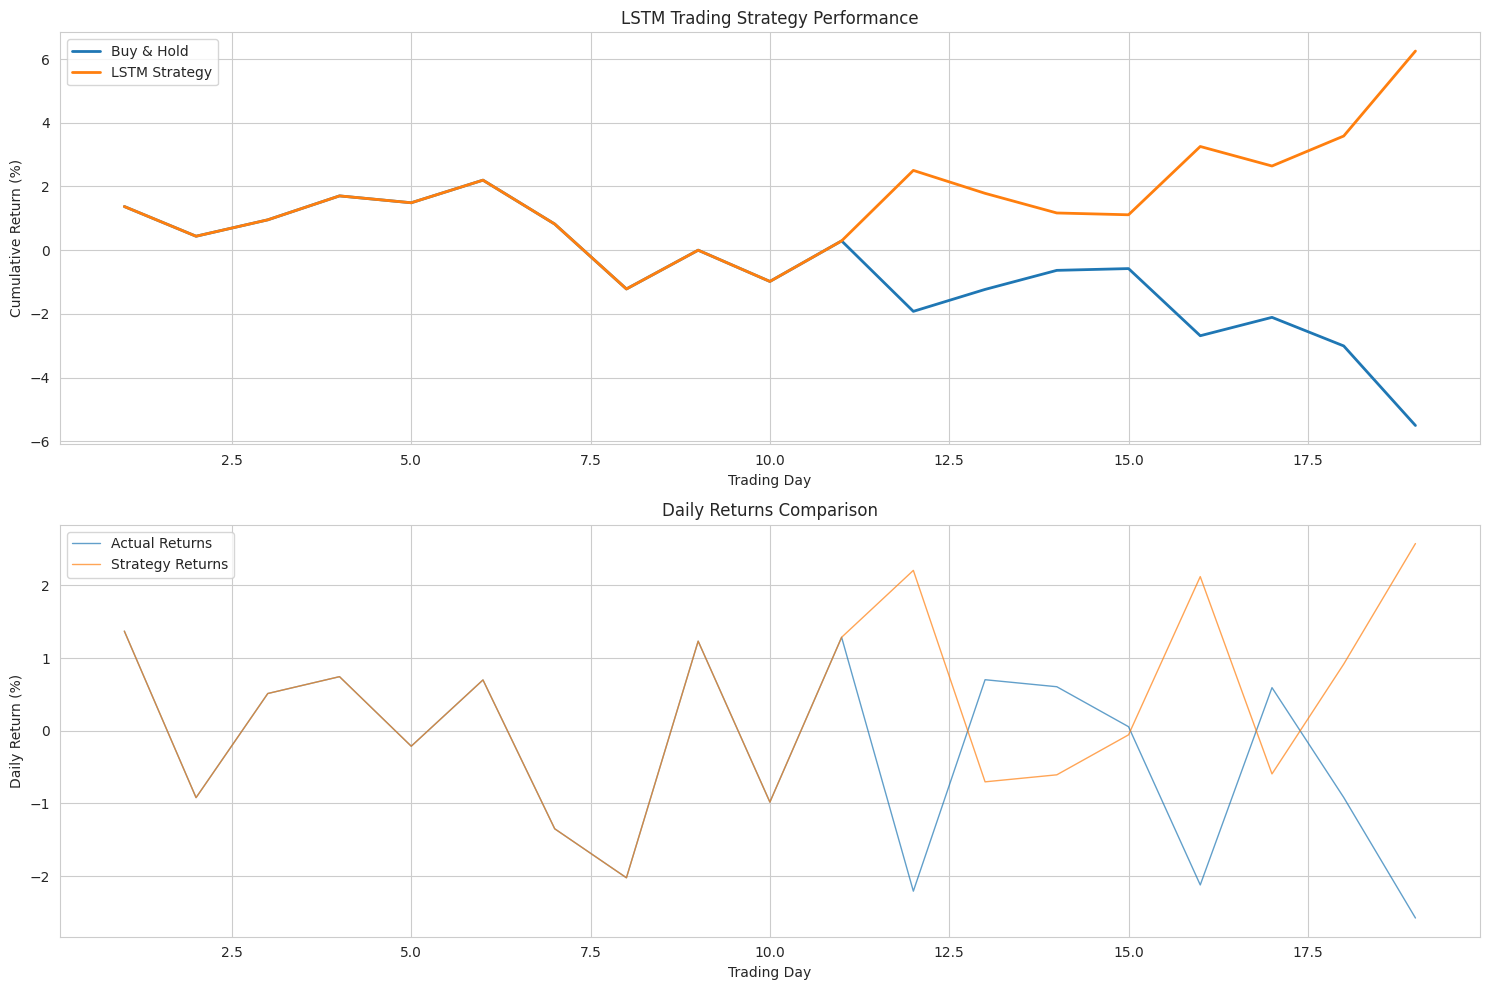

Backtest results plot saved to outputs/lstm/backtest_results.png


In [13]:
# Plot backtest results
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Cumulative returns
axes[0].plot(test_df['Cumulative_Returns'] * 100, label='Buy & Hold', linewidth=2)
axes[0].plot(test_df['Cumulative_Strategy_Returns'] * 100, label='LSTM Strategy', linewidth=2)
axes[0].set_xlabel('Trading Day')
axes[0].set_ylabel('Cumulative Return (%)')
axes[0].set_title('LSTM Trading Strategy Performance')
axes[0].legend()
axes[0].grid(True)

# Daily returns
axes[1].plot(test_df['Returns'] * 100, label='Actual Returns', alpha=0.7, linewidth=1)
axes[1].plot(test_df['Strategy_Returns'] * 100, label='Strategy Returns', alpha=0.7, linewidth=1)
axes[1].set_xlabel('Trading Day')
axes[1].set_ylabel('Daily Return (%)')
axes[1].set_title('Daily Returns Comparison')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('outputs/lstm/backtest_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("Backtest results plot saved to outputs/lstm/backtest_results.png")

## 10. Save Results Summary

In [14]:
# Save all metrics to file
results_summary = {
    'model': 'LSTM',
    'architecture': {
        'hidden_size': 128,
        'num_layers': 2,
        'dropout': 0.3,
        'total_params': sum(p.numel() for p in model.parameters())
    },
    'training': {
        'epochs': num_epochs,
        'batch_size': batch_size,
        'learning_rate': 0.001,
        'training_time': training_time
    },
    'metrics': {
        'accuracy': float(accuracy),
        'f1_score': float(f1),
        'precision': float(precision),
        'recall': float(recall),
        'avg_inference_time_ms': float(avg_inference_time)
    },
    'backtesting': {
        'sharpe_ratio': float(sharpe_ratio),
        'total_return': float(test_df['Cumulative_Strategy_Returns'].iloc[-1]),
        'buy_hold_return': float(test_df['Cumulative_Returns'].iloc[-1]),
        'win_rate': float(test_df['Correct'].mean())
    }
}

# Save to pickle
with open('outputs/lstm/results_summary.pkl', 'wb') as f:
    pickle.dump(results_summary, f)

# Save to text file
with open('outputs/lstm/results_summary.txt', 'w') as f:
    f.write("LSTM STOCK PREDICTION RESULTS SUMMARY\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("ARCHITECTURE:\n")
    for key, value in results_summary['architecture'].items():
        f.write(f"  {key}: {value}\n")
    
    f.write("\nTRAINING:\n")
    for key, value in results_summary['training'].items():
        f.write(f"  {key}: {value}\n")
    
    f.write("\nMETRICS:\n")
    for key, value in results_summary['metrics'].items():
        f.write(f"  {key}: {value:.4f}\n")
    
    f.write("\nBACKTESTING:\n")
    for key, value in results_summary['backtesting'].items():
        f.write(f"  {key}: {value:.4f}\n")

print("Results summary saved to outputs/lstm/results_summary.pkl and .txt")
print("\nLSTM training and evaluation complete!")

Results summary saved to outputs/lstm/results_summary.pkl and .txt

LSTM training and evaluation complete!


## 11. Compare with SNN Results


SNN vs LSTM COMPARISON
             Metric     SNN   LSTM
       Accuracy (%)   50.00  45.00
           F1 Score  0.6429 0.4762
          Precision  0.5000 0.4545
             Recall  0.9000 0.5000
Inference Time (ms)    2.67   0.34
       Sharpe Ratio -5.3646 4.0192
Strategy Return (%)   -7.94   6.25
       Win Rate (%)   50.00  45.00

Comparison saved to outputs/model_comparison.csv


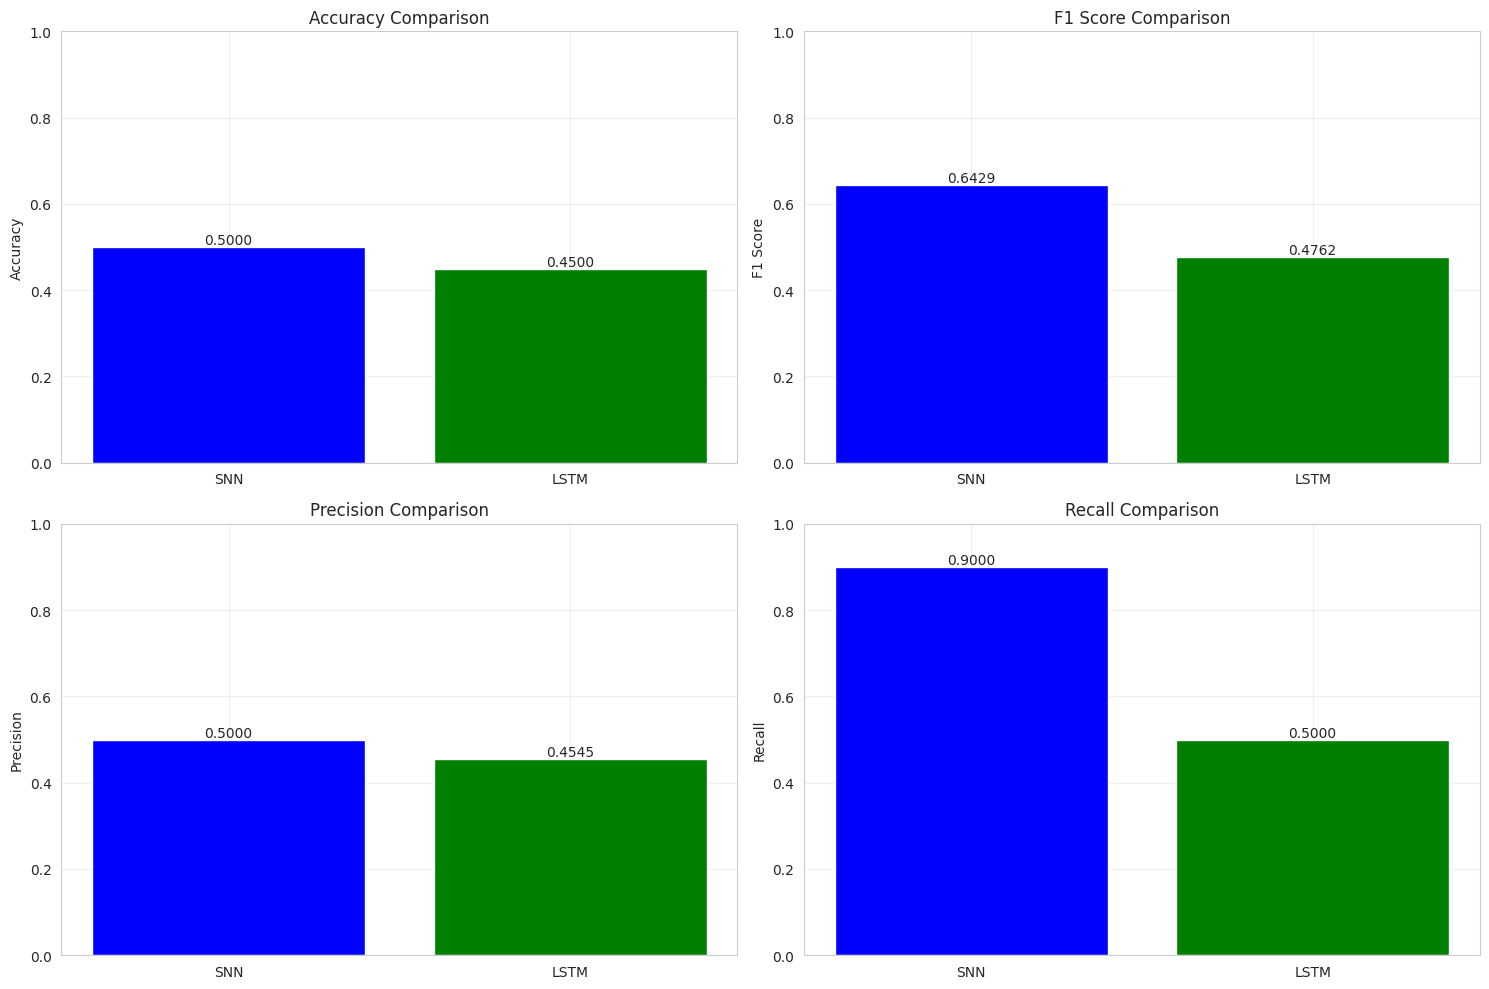

Comparison plot saved to outputs/model_comparison.png


In [16]:
# Load SNN results if available
try:
    with open('outputs/snn/results_summary.pkl', 'rb') as f:
        snn_results = pickle.load(f)
    
    print("\n" + "=" * 80)
    print("SNN vs LSTM COMPARISON")
    print("=" * 80)
    
    # Create comparison table
    comparison_data = {
        'Metric': ['Accuracy (%)', 'F1 Score', 'Precision', 'Recall', 
                   'Inference Time (ms)', 'Sharpe Ratio', 'Strategy Return (%)', 'Win Rate (%)'],
        'SNN': [
            f"{snn_results['metrics']['accuracy']*100:.2f}",
            f"{snn_results['metrics']['f1_score']:.4f}",
            f"{snn_results['metrics']['precision']:.4f}",
            f"{snn_results['metrics']['recall']:.4f}",
            f"{snn_results['metrics']['avg_inference_time_ms']:.2f}",
            f"{snn_results['backtesting']['sharpe_ratio']:.4f}",
            f"{snn_results['backtesting']['total_return']*100:.2f}",
            f"{snn_results['backtesting']['win_rate']*100:.2f}"
        ],
        'LSTM': [
            f"{results_summary['metrics']['accuracy']*100:.2f}",
            f"{results_summary['metrics']['f1_score']:.4f}",
            f"{results_summary['metrics']['precision']:.4f}",
            f"{results_summary['metrics']['recall']:.4f}",
            f"{results_summary['metrics']['avg_inference_time_ms']:.2f}",
            f"{results_summary['backtesting']['sharpe_ratio']:.4f}",
            f"{results_summary['backtesting']['total_return']*100:.2f}",
            f"{results_summary['backtesting']['win_rate']*100:.2f}"
        ]
    }
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    print("=" * 80)
    
    # Save comparison
    comparison_df.to_csv('outputs/model_comparison.csv', index=False)
    print("\nComparison saved to outputs/model_comparison.csv")
    
    # Create visual comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    metrics = ['accuracy', 'f1_score', 'precision', 'recall']
    titles = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        row = idx // 2
        col = idx % 2
        
        snn_val = snn_results['metrics'][metric]
        lstm_val = results_summary['metrics'][metric]
        
        bars = axes[row, col].bar(['SNN', 'LSTM'], [snn_val, lstm_val], color=['blue', 'green'])
        axes[row, col].set_ylabel(title)
        axes[row, col].set_title(f'{title} Comparison')
        axes[row, col].set_ylim([0, 1])
        axes[row, col].grid(True, alpha=0.3)
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            axes[row, col].text(bar.get_x() + bar.get_width()/2., height,
                               f'{height:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('outputs/model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Comparison plot saved to outputs/model_comparison.png")
    
except FileNotFoundError:
    print("\nSNN results not found. Run SNN notebook first to enable comparison.")